<a href="https://colab.research.google.com/github/marko04st/MLProjects/blob/main/Card_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import pandas as pd
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import os

### За да можете да заредите Kaggle dataset, трябва да се логнете в Kaggle и да изтеглите API Token от Settings -> Create New Token. Това ще свали kaggle.json файл, който трябва да качите в следващата клетка.

In [ ]:
files.upload()
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
! kaggle datasets download -d gpiosenka/cards-image-datasetclassification
! unzip cards-image-datasetclassification.zip -d cards-image-datasetclassification

Streaming output truncated to the last 5000 lines.
  inflating: cards-image-datasetclassification/train/jack of spades/059.jpg  
  inflating: cards-image-datasetclassification/train/jack of spades/060.jpg  
  inflating: cards-image-datasetclassification/train/jack of spades/061.jpg  
  inflating: cards-image-datasetclassification/train/jack of spades/062.jpg  
  inflating: cards-image-datasetclassification/train/jack of spades/063.jpg  
  inflating: cards-image-datasetclassification/train/jack of spades/064.jpg  
  inflating: cards-image-datasetclassification/train/jack of spades/065.jpg  
  inflating: cards-image-datasetclassification/train/jack of spades/066.jpg  
  inflating: cards-image-datasetclassification/train/jack of spades/067.jpg  
  inflating: cards-image-datasetclassification/train/jack of spades/068.jpg  
  inflating: cards-image-datasetclassification/train/jack of spades/069.jpg  
  inflating: cards-image-datasetclassification/train/jack of spades/070.jpg  
  inflating: 

In [ ]:
df = pd.read_csv("/content/cards-image-datasetclassification/cards.csv")
df.head()

,class index,filepaths,labels,card type,data set
0,0,train/ace of clubs/001.jpg,ace of clubs,ace,train
1,0,train/ace of clubs/002.jpg,ace of clubs,ace,train
2,0,train/ace of clubs/003.jpg,ace of clubs,ace,train
3,0,train/ace of clubs/004.jpg,ace of clubs,ace,train
4,0,train/ace of clubs/005.jpg,ace of clubs,ace,train


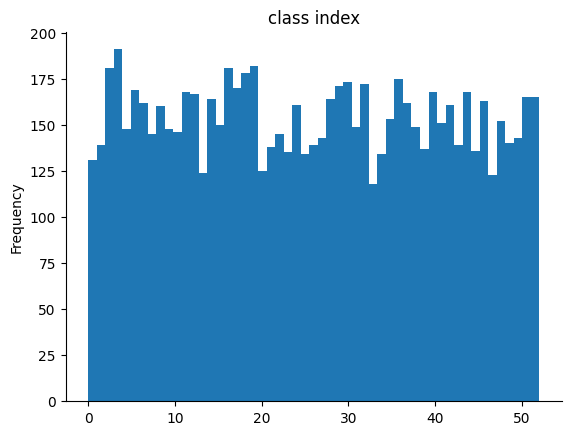

In [ ]:
# @title class index

from matplotlib import pyplot as plt
df['class index'].plot(kind='hist', bins=53, title='class index')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
df[df["data set"] == "train"].shape, df[df["data set"] == "valid"].shape, df[df["data set"] == "test"].shape,

((7625, 5), (265, 5), (265, 5))

In [ ]:
df["labels"].unique()

array(['ace of clubs', 'ace of diamonds', 'ace of hearts',
       'ace of spades', 'eight of clubs', 'eight of diamonds',
       'eight of hearts', 'eight of spades', 'five of clubs',
       'five of diamonds', 'five of hearts', 'five of spades',
       'four of clubs', 'four of diamonds', 'four of hearts',
       'four of spades', 'jack of clubs', 'jack of diamonds',
       'jack of hearts', 'jack of spades', 'joker', 'king of clubs',
       'king of diamonds', 'king of hearts', 'king of spades',
       'nine of clubs', 'nine of diamonds', 'nine of hearts',
       'nine of spades', 'queen of clubs', 'queen of diamonds',
       'queen of hearts', 'queen of spades', 'seven of clubs',
       'seven of diamonds', 'seven of hearts', 'seven of spades',
       'six of clubs', 'six of diamonds', 'six of hearts',
       'six of spades', 'ten of clubs', 'ten of diamonds',
       'ten of hearts', 'ten of spades', 'three of clubs',
       'three of diamonds', 'three of hearts', 'three of spades',

<function matplotlib.pyplot.show(close=None, block=None)>

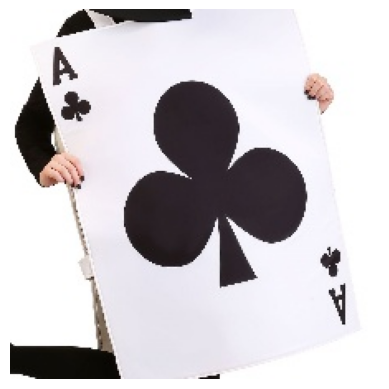

In [ ]:
img = Image.open("cards-image-datasetclassification/train/ace of clubs/001.jpg")

plt.imshow(img)
plt.axis("off")
plt.show

In [ ]:
training_df = df[df["data set"] == "train"]
validating_df = df[df["data set"] == "valid"]
testing_df = df[df["data set"] == "test"]


In [ ]:
bad_filepaths = training_df[training_df['filepaths'].str.contains('output', na=False)]
print("Rows in training_df where 'filepaths' contains 'output':")
display(bad_filepaths)

Rows in training_df where 'filepaths' contains 'output':


,class index,filepaths,labels,card type,data set
120,0,train/ace of clubs/output,ace of clubs,ace,train


In [ ]:
training_df = training_df.copy()
training_df.drop(training_df[training_df['filepaths'].str.contains('output', na=False)].index, inplace=True)

In [ ]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, img_dir=" ", transform = None):
    self.df = dataframe.reset_index(drop=True)
    self.img_dir = img_dir
    self.transform = transform

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    img_path = os.path.join(self.img_dir, self.df.loc[idx, "filepaths"])
    image = Image.open(img_path).convert("RGB")
    label = int(self.df.loc[idx, "class index"])

    image = self.transform(image)

    return image, label

transform = ToTensor()

root_dir = "/content/cards-image-datasetclassification"

train_dataset = CustomImageDataset(training_df, img_dir=root_dir, transform=transform)
valid_dataset = CustomImageDataset(validating_df, img_dir=root_dir, transform=transform)
test_dataset  = CustomImageDataset(testing_df, img_dir=root_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
for images, labels in train_loader:
  print(f"N, C, H, W =", images.shape)
  print(labels.shape)
  print(images.dtype)
  break

N, C, H, W = torch.Size([32, 3, 224, 224])
torch.Size([32])
torch.float32


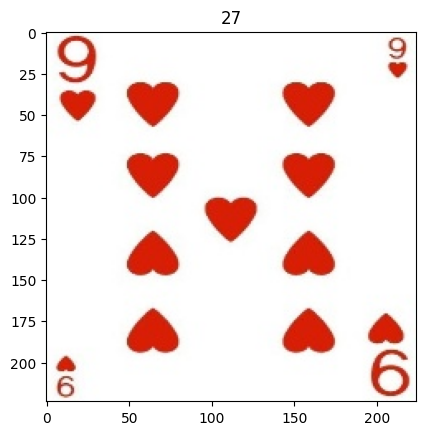

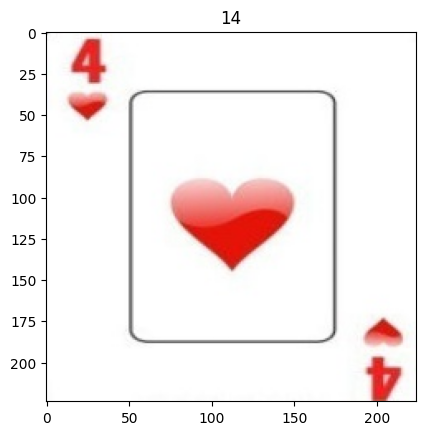

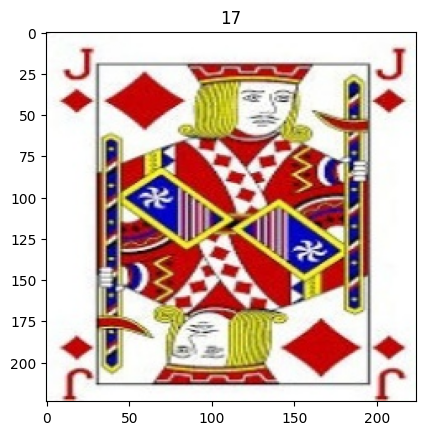

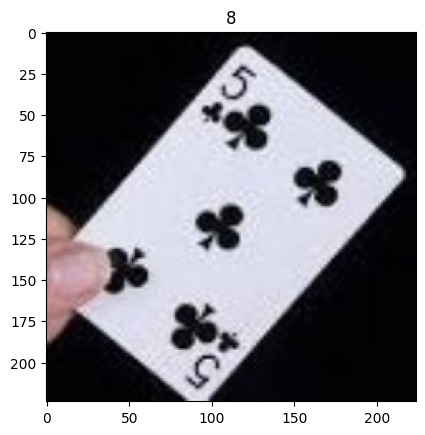

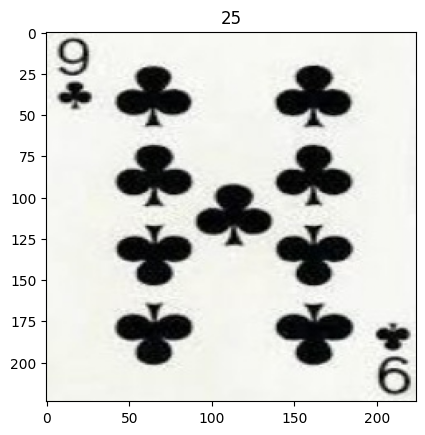

In [ ]:
images, labels = next(iter(train_loader))
for i in range(5):
    img = images[i].permute(1,2,0)
    plt.imshow(img)
    plt.title(labels[i].item())
    plt.show()

In [ ]:
from torch.nn.modules.conv import Conv2d
class CNN1(nn.Module):
  def __init__(self, dropout):
    self.dropout = dropout
    super().__init__()
    self.conv_layers = nn.Sequential(
        nn.Conv2d(in_channels = 3, out_channels = 32, kernel_size=4, stride = 2, padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2),
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=4, stride=2, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2),
        nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)
    )
    self.linear_layers = nn.Sequential(
        nn.Flatten(),
        nn.Dropout(self.dropout),
        nn.Linear(7*7*128, 512),
        nn.ReLU(),
        nn.Dropout(self.dropout),
        nn.Linear(512, 53)
    )
  def forward(self, x):
    x = self.conv_layers(x)
    x = self.linear_layers(x)
    return x



model1 = CNN1(0.3)
model2 = CNN1(0.2)
print(model2)

CNN1(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (linear_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.2, inplace=False)
    (2): Linear(in_features=6272, out_features=512, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.2, inplace=False)
    (5): Linear(in_features=512, out_features=53, bias=True)
  )
)


In [ ]:
optimizer_model1 = torch.optim.Adam(model1.parameters(), lr=0.001)
optimizer_model2 = torch.optim.Adam(model2.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

In [ ]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 20 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [ ]:
def validate(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Validation Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [ ]:
def reset_weights(m):
    if hasattr(m, "reset_parameters"):
        m.reset_parameters()


In [ ]:
epochs = 10
model1.apply(reset_weights)
for i in range(1, epochs + 1):
  print(f"Epoch {i}\n------------------------")
  train(train_loader, model1, loss_fn, optimizer_model1)
  validate(valid_loader, model1, loss_fn)

Epoch 1
------------------------
loss: 3.968350  [   32/ 7624]
loss: 3.985974  [  672/ 7624]
loss: 3.964744  [ 1312/ 7624]
loss: 3.967619  [ 1952/ 7624]
loss: 3.955896  [ 2592/ 7624]
loss: 3.970843  [ 3232/ 7624]
loss: 3.964722  [ 3872/ 7624]
loss: 3.941790  [ 4512/ 7624]
loss: 3.891292  [ 5152/ 7624]
loss: 3.771497  [ 5792/ 7624]
loss: 3.390977  [ 6432/ 7624]
loss: 3.404106  [ 7072/ 7624]
Validation Error: 
 Accuracy: 18.1%, Avg loss: 2.821746 

Epoch 2
------------------------
loss: 2.968024  [   32/ 7624]
loss: 3.079287  [  672/ 7624]
loss: 2.763822  [ 1312/ 7624]
loss: 2.519100  [ 1952/ 7624]
loss: 2.343641  [ 2592/ 7624]
loss: 2.994589  [ 3232/ 7624]
loss: 2.552455  [ 3872/ 7624]
loss: 2.795854  [ 4512/ 7624]
loss: 2.562040  [ 5152/ 7624]
loss: 2.320631  [ 5792/ 7624]
loss: 2.879969  [ 6432/ 7624]
loss: 2.306906  [ 7072/ 7624]
Validation Error: 
 Accuracy: 44.5%, Avg loss: 1.814538 

Epoch 3
------------------------
loss: 2.231116  [   32/ 7624]
loss: 2.523461  [  672/ 7624]
loss:

In [ ]:
epochs = 10
model2.apply(reset_weights)
for i in range(1, epochs + 1):
  print(f"Epoch {i}\n------------------------")
  train(train_loader, model2, loss_fn, optimizer_model2)
  validate(valid_loader, model2, loss_fn)

Epoch 1
------------------------
loss: 3.975060  [   32/ 7624]
loss: 3.974745  [  672/ 7624]
loss: 3.904844  [ 1312/ 7624]
loss: 3.859166  [ 1952/ 7624]
loss: 3.464730  [ 2592/ 7624]
loss: 3.166736  [ 3232/ 7624]
loss: 2.823319  [ 3872/ 7624]
loss: 2.745040  [ 4512/ 7624]
loss: 2.917441  [ 5152/ 7624]
loss: 2.803114  [ 5792/ 7624]
loss: 2.411853  [ 6432/ 7624]
loss: 2.742255  [ 7072/ 7624]
Validation Error: 
 Accuracy: 33.6%, Avg loss: 2.070815 

Epoch 2
------------------------
loss: 2.311647  [   32/ 7624]
loss: 2.772987  [  672/ 7624]
loss: 2.268602  [ 1312/ 7624]
loss: 2.522614  [ 1952/ 7624]
loss: 1.992713  [ 2592/ 7624]
loss: 2.368263  [ 3232/ 7624]
loss: 2.453263  [ 3872/ 7624]
loss: 1.817163  [ 4512/ 7624]
loss: 1.692120  [ 5152/ 7624]
loss: 1.721546  [ 5792/ 7624]
loss: 1.676802  [ 6432/ 7624]
loss: 2.157892  [ 7072/ 7624]
Validation Error: 
 Accuracy: 50.9%, Avg loss: 1.480340 

Epoch 3
------------------------
loss: 2.020838  [   32/ 7624]
loss: 1.751379  [  672/ 7624]
loss: